In [54]:
import numpy as np
from tensorflow.keras.models import load_model

In [55]:
model = load_model("ml4h/model_zoo/PCLR/c3po_pclr.h5")
ecg_data = np.load('data/ptbxl_pclr_format/00000/00001_lr.npy')


x = np.zeros((1, 4096, 12))
y = model(x)

print(y.shape)

(1, 320)


# Fine-tuning PCLR Model

This notebook demonstrates different approaches to fine-tune the PCLR model for downstream tasks.

In [56]:
import sys
sys.path.append('ml4h/model_zoo/PCLR')

from build_model import get_model
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

## Approach 1: Add Task-Specific Head (Recommended for Classification/Regression)

This approach freezes the encoder and only trains a new classification/regression head.

In [57]:
def create_finetune_model_with_head(base_model, num_classes=2, task_type='classification'):
    """
    Create a fine-tuned model by adding a task-specific head on top of PCLR encoder.
    
    Args:
        base_model: Pre-trained PCLR model
        num_classes: Number of output classes (for classification) or 1 (for regression)
        task_type: 'classification' or 'regression'
    
    Returns:
        Compiled model ready for training
    """
    # Get the embedding layer (before projection head)
    # The PCLR model has: encoder -> GlobalAveragePooling1D -> projection layers -> output
    # We want to get the embedding before the projection layers
    embedding_layer = None
    for layer in base_model.layers:
        if layer.name == 'embed':  # This is the GlobalAveragePooling1D layer
            embedding_layer = layer.output
            break
    
    if embedding_layer is None:
        # If 'embed' layer not found, use the layer before the last Dense layer
        embedding_layer = base_model.layers[-2].output
    
    # Freeze the base model
    base_model.trainable = False
    
    # Add task-specific head
    x = embedding_layer
    x = Dense(128, activation='relu', name='task_dense_1')(x)
    x = Dropout(0.3, name='task_dropout')(x)
    
    if task_type == 'classification':
        if num_classes == 2:
            output = Dense(1, activation='sigmoid', name='task_output')(x)
            loss = 'binary_crossentropy'
            metrics = ['accuracy']
        else:
            output = Dense(num_classes, activation='softmax', name='task_output')(x)
            loss = 'categorical_crossentropy'
            metrics = ['accuracy']
    else:  # regression
        output = Dense(1, activation='linear', name='task_output')(x)
        loss = 'mse'
        metrics = ['mae']
    
    # Create new model
    finetune_model = Model(inputs=base_model.input, outputs=output)
    
    # Compile with lower learning rate for fine-tuning
    finetune_model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss=loss,
        metrics=metrics
    )
    
    return finetune_model

# Example usage:
finetune_model = create_finetune_model_with_head(model, num_classes=2, task_type='classification')
finetune_model.summary()

Model: "functional_25"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ ecg (InputLayer)    │ (None, 4096, 12)  │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 4096, 64)  │     12,288 │ ecg[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 4096, 64)  │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 4096, 64)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 4096, 128) │    131,072 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 4096, 128) │        512 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 4096, 128) │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 1024, 64)  │          0 │ activation[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 1024, 128) │    262,144 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 1024, 128) │      8,192 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1024, 128) │          0 │ conv1d_3[0][0],   │
│                     │                   │            │ conv1d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1024, 128) │        512 │ add[0][0]         │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 1024, 128) │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 1024, 196) │    401,408 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1024, 196) │        784 │ conv1d_5[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 1024, 196) │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 256, 128)  │          0 │ add[0][0]         │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 256, 196)  │    614,656 │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 256, 196)  │     25,088 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 6,436,129 (24.55 MB)

 Trainable params: 41,217 (161.00 KB)

 Non-trainable params: 6,394,912 (24.39 MB)

## Approach 2: Unfreeze Last Layers (Transfer Learning)

This approach unfreezes the last few layers of the encoder for end-to-end fine-tuning.

In [58]:
def create_finetune_model_unfreeze_layers(base_model, num_classes=2, task_type='classification', 
                                         num_layers_to_unfreeze=3):
    """
    Create a fine-tuned model by unfreezing the last N layers of the encoder.
    
    Args:
        base_model: Pre-trained PCLR model
        num_classes: Number of output classes
        task_type: 'classification' or 'regression'
        num_layers_to_unfreeze: Number of encoder layers to unfreeze (from the end)
    
    Returns:
        Compiled model ready for training
    """
    # Freeze all layers first
    base_model.trainable = False
    
    # Unfreeze the last N layers
    total_layers = len(base_model.layers)
    for i in range(total_layers - num_layers_to_unfreeze, total_layers):
        base_model.layers[i].trainable = True
    
    # Get embedding layer
    embedding_layer = None
    for layer in base_model.layers:
        if layer.name == 'embed':
            embedding_layer = layer.output
            break
    
    if embedding_layer is None:
        embedding_layer = base_model.layers[-2].output
    
    # Add task-specific head
    x = embedding_layer
    x = Dense(128, activation='relu', name='task_dense_1')(x)
    x = Dropout(0.3, name='task_dropout')(x)
    
    if task_type == 'classification':
        if num_classes == 2:
            output = Dense(1, activation='sigmoid', name='task_output')(x)
            loss = 'binary_crossentropy'
            metrics = ['accuracy']
        else:
            output = Dense(num_classes, activation='softmax', name='task_output')(x)
            loss = 'categorical_crossentropy'
            metrics = ['accuracy']
    else:  # regression
        output = Dense(1, activation='linear', name='task_output')(x)
        loss = 'mse'
        metrics = ['mae']
    
    finetune_model = Model(inputs=base_model.input, outputs=output)
    
    # Use lower learning rate for fine-tuning
    finetune_model.compile(
        optimizer=Adam(learning_rate=1e-5),  # Lower LR since we're training encoder layers
        loss=loss,
        metrics=metrics
    )
    
    return finetune_model

# Example usage:
finetune_model = create_finetune_model_unfreeze_layers(model, num_classes=2, 
                                                       num_layers_to_unfreeze=3)

## Approach 3: Replace Projection Head and Fine-tune

This approach replaces the PCLR projection head with a task-specific head and fine-tunes the entire model.

In [59]:
def create_finetune_model_replace_projection(base_model, num_classes=2, task_type='classification'):
    """
    Replace the PCLR projection head with a task-specific head and fine-tune everything.
    
    Args:
        base_model: Pre-trained PCLR model
        num_classes: Number of output classes
        task_type: 'classification' or 'regression'
    
    Returns:
        Compiled model ready for training
    """
    # Get the embedding layer (before projection)
    embedding_layer = None
    for layer in base_model.layers:
        if layer.name == 'embed':
            embedding_layer = layer.output
            break
    
    if embedding_layer is None:
        embedding_layer = base_model.layers[-2].output
    
    # Make base model trainable (but use lower learning rate)
    base_model.trainable = True
    
    # Replace projection head with task-specific head
    x = embedding_layer
    x = Dense(256, activation='relu', name='task_dense_1')(x)
    x = Dropout(0.4, name='task_dropout_1')(x)
    x = Dense(128, activation='relu', name='task_dense_2')(x)
    x = Dropout(0.3, name='task_dropout_2')(x)
    
    if task_type == 'classification':
        if num_classes == 2:
            output = Dense(1, activation='sigmoid', name='task_output')(x)
            loss = 'binary_crossentropy'
            metrics = ['accuracy']
        else:
            output = Dense(num_classes, activation='softmax', name='task_output')(x)
            loss = 'categorical_crossentropy'
            metrics = ['accuracy']
    else:  # regression
        output = Dense(1, activation='linear', name='task_output')(x)
        loss = 'mse'
        metrics = ['mae']
    
    finetune_model = Model(inputs=base_model.input, outputs=output)
    
    # Use differential learning rates: lower for encoder, higher for new head
    # This requires a custom optimizer setup
    finetune_model.compile(
        optimizer=Adam(learning_rate=1e-5),  # Conservative LR for full fine-tuning
        loss=loss,
        metrics=metrics
    )
    
    return finetune_model

# Example usage:
# finetune_model = create_finetune_model_replace_projection(model, num_classes=2)

## Training Example

Example of how to train the fine-tuned model with your data.

In [60]:
# # Example training code (uncomment and modify for your use case):

# # Load and preprocess your data
# # X_train, X_val: numpy arrays of shape (N, 4096, 12) - your ECG data
# # y_train, y_val: numpy arrays of shape (N,) or (N, num_classes) - your labels

# # Create fine-tuned model (choose one approach)
# finetune_model = create_finetune_model_with_head(model, num_classes=2, task_type='classification')

# # Optional: Use callbacks for better training
# from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# callbacks = [
#     EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
#     ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7),
#     ModelCheckpoint('best_pclr_finetuned.h5', monitor='val_loss', save_best_only=True)
# ]

# # Train the model
# history = finetune_model.fit(
#     X_train, y_train,
#     batch_size=32,
#     epochs=100,
#     validation_data=(X_val, y_val),
#     callbacks=callbacks,
#     verbose=1
# )

## Key Fine-tuning Tips

1. **Start with Approach 1** (frozen encoder + new head) - it's the safest and often works well
2. **Learning Rates**: 
   - Frozen encoder: 1e-3 to 1e-4 for new head
   - Unfrozen layers: 1e-5 to 1e-6 for encoder, 1e-4 for head
3. **Data Requirements**: Fine-tuning typically needs less data than training from scratch
4. **Progressive Unfreezing**: Start with frozen encoder, then gradually unfreeze layers if needed
5. **Regularization**: Use dropout and early stopping to prevent overfitting
6. **Input Format**: Ensure your ECGs are preprocessed correctly:
   - Shape: (N, 4096, 12) for 12-lead ECGs
   - Values in millivolts
   - 10 seconds of data interpolated to 4096 samples

# Multi-Task Learning: Predicting Age and Sex

This section guides you through fine-tuning PCLR to predict both **age** (regression) and **sex** (classification) simultaneously.

In [61]:
# Step 1: Load required libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

## Step 2: Load Your Data

Load the ECG data and labels from the PTB-XL dataset.

In [62]:
# Load the labels CSV
labels_df = pd.read_csv('data/ptbxl_with_labels/ecg_with_labels.csv')

print(f"Loaded {len(labels_df)} ECG records")
print(f"\nAge statistics:")
print(f"  Mean: {labels_df['age'].mean():.1f} years")
print(f"  Range: {labels_df['age'].min():.0f} - {labels_df['age'].max():.0f} years")
print(f"\nSex distribution:")
print(labels_df['sex'].value_counts().to_string())

# Load ECG data
print("\nLoading ECG data...")
ecg_files = labels_df['ecg_file'].tolist()
X = np.array([np.load(f) for f in ecg_files])  # Shape: (50, 4096, 12)

# Extract labels
y_age = labels_df['age'].values.astype(np.float32)  # Regression target
y_sex = labels_df['sex'].values.astype(np.int32)    # Classification target

print(f"\nData shapes:")
print(f"  ECGs (X): {X.shape}")
print(f"  Age (y_age): {y_age.shape}")
print(f"  Sex (y_sex): {y_sex.shape}")

Loaded 50 ECG records

Age statistics:
  Mean: 37.8 years
  Range: 17 - 60 years

Sex distribution:
sex
0    28
1    22

Loading ECG data...

Data shapes:
  ECGs (X): (50, 4096, 12)
  Age (y_age): (50,)
  Sex (y_sex): (50,)


## Step 3: Create Multi-Task Model

Create a model that predicts both age and sex from the same ECG representation.

In [63]:
def create_multi_task_model(base_model):
    """
    Create a multi-task model that predicts both age and sex.
    
    Args:
        base_model: Pre-trained PCLR model
    
    Returns:
        Compiled multi-task model
    """
    # Freeze the base model encoder
    base_model.trainable = False
    
    # Get the embedding layer (before projection head)
    embedding_layer = None
    for layer in base_model.layers:
        if layer.name == 'embed':  # GlobalAveragePooling1D layer
            embedding_layer = layer.output
            break
    
    if embedding_layer is None:
        # Fallback: use the layer before the last Dense layer
        embedding_layer = base_model.layers[-2].output
    
    # Shared layers for both tasks
    x = embedding_layer
    x = Dense(128, activation='relu', name='shared_dense_1')(x)
    x = Dropout(0.3, name='shared_dropout')(x)
    x = Dense(64, activation='relu', name='shared_dense_2')(x)
    
    # Task-specific heads
    # Age prediction (regression)
    age_output = Dense(1, activation='linear', name='age_output')(x)
    
    # Sex prediction (binary classification)
    sex_output = Dense(1, activation='sigmoid', name='sex_output')(x)
    
    # Create multi-task model
    multi_task_model = Model(
        inputs=base_model.input,
        outputs=[age_output, sex_output],
        name='pclr_multi_task_age_sex'
    )
    
    # Compile with separate losses and metrics for each task
    multi_task_model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss={
            'age_output': 'mse',      # Mean squared error for regression
            'sex_output': 'binary_crossentropy'  # Binary crossentropy for classification
        },
        loss_weights={
            'age_output': 1.0,       # Equal weight for both tasks
            'sex_output': 1.0
        },
        metrics={
            'age_output': 'mae',     # Mean absolute error
            'sex_output': 'accuracy' # Classification accuracy
        }
    )
    
    return multi_task_model

# Create the model
print("Creating multi-task model...")
multi_task_model = create_multi_task_model(model)
multi_task_model.summary()

Creating multi-task model...


Model: "pclr_multi_task_age_sex"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ ecg (InputLayer)    │ (None, 4096, 12)  │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 4096, 64)  │     12,288 │ ecg[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 4096, 64)  │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 4096, 64)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 4096, 128) │    131,072 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 4096, 128) │        512 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 4096, 128) │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 1024, 64)  │          0 │ activation[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 1024, 128) │    262,144 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 1024, 128) │      8,192 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1024, 128) │          0 │ conv1d_3[0][0],   │
│                     │                   │            │ conv1d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1024, 128) │        512 │ add[0][0]         │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 1024, 128) │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 1024, 196) │    401,408 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1024, 196) │        784 │ conv1d_5[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 1024, 196) │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 256, 128)  │          0 │ add[0][0]         │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 256, 196)  │    614,656 │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 256, 196)  │     25,088 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 6,444,386 (24.58 MB)

 Trainable params: 50,114 (195.76 KB)

 Non-trainable params: 6,394,272 (24.39 MB)

## Step 4: Prepare Training Data

Split the data into training and validation sets.

In [64]:
# Split data into train and validation sets
# Using 80/20 split
X_train, X_val, y_age_train, y_age_val, y_sex_train, y_sex_val = train_test_split(
    X, y_age, y_sex,
    test_size=0.2,
    random_state=42,
    stratify=y_sex  # Stratify by sex to maintain class balance
)

print(f"Training set: {len(X_train)} samples")
print(f"Validation set: {len(X_val)} samples")
print(f"\nTraining age: {y_age_train.mean():.1f} ± {y_age_train.std():.1f} years")
print(f"Validation age: {y_age_val.mean():.1f} ± {y_age_val.std():.1f} years")
print(f"\nTraining sex distribution:")
print(f"  Female (0): {(y_sex_train == 0).sum()}")
print(f"  Male (1): {(y_sex_train == 1).sum()}")
print(f"\nValidation sex distribution:")
print(f"  Female (0): {(y_sex_val == 0).sum()}")
print(f"  Male (1): {(y_sex_val == 1).sum()}")

Training set: 40 samples
Validation set: 10 samples

Training age: 36.5 ± 15.6 years
Validation age: 42.7 ± 15.9 years

Training sex distribution:
  Female (0): 22
  Male (1): 18

Validation sex distribution:
  Female (0): 6
  Male (1): 4


## Step 5: Train the Model

Train the multi-task model with callbacks for better training.

In [65]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Set up callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        'best_pclr_age_sex.keras',  # Use .keras extension
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

# Train the model
print("Starting training...")
print("=" * 60)

history = multi_task_model.fit(
    X_train,
    [y_age_train, y_sex_train],  # Multiple outputs
    batch_size=8,  # Small batch size for 40 training samples
    epochs=100,
    validation_data=(X_val, [y_age_val, y_sex_val]),
    callbacks=callbacks,
    verbose=1
)

print("\nTraining complete!")

Starting training...
Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - age_output_mae: 31.1791 - loss: 1152.6539 - sex_output_accuracy: 0.5587
Epoch 1: val_loss improved from inf to 1193.91748, saving model to best_pclr_age_sex.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 272ms/step - age_output_mae: 31.1613 - loss: 1154.5563 - sex_output_accuracy: 0.5615 - val_age_output_mae: 35.3927 - val_loss: 1193.9175 - val_sex_output_accuracy: 0.8000 - learning_rate: 1.0000e-04
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - age_output_mae: 26.6304 - loss: 936.4159 - sex_output_accuracy: 0.4929
Epoch 2: val_loss improved from 1193.91748 to 1022.27496, saving model to best_pclr_age_sex.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 167ms/step - age_output_mae: 26.8298 - loss: 945.4760 - sex_output_accuracy: 0.4899 - val_age_output_mae: 32.5152 - val_loss: 1022.2750 - val_sex_output_accuracy: 0.8000 - learning_rate: 1.0000e-04
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - age_output_mae: 26.9845 - loss: 955

## Step 6: Evaluate the Model

Check how well the model performs on both tasks.

In [71]:
# Evaluate on validation set
print("Evaluating on validation set...")
print("=" * 60)

val_results = multi_task_model.evaluate(
    X_val,
    [y_age_val, y_sex_val],
    verbose=1
)

# Map results using model.metrics_names for correct indexing
results_dict = dict(zip(multi_task_model.metrics_names, val_results))

print(f"\nValidation Results:")
print(f"  Total Loss: {results_dict.get('loss', val_results[0]):.4f}")

# Make predictions first (we'll use these to compute metrics manually)
print("\nMaking predictions...")
predictions = multi_task_model.predict(X_val, verbose=0)
pred_age = predictions[0].flatten()
pred_sex = (predictions[1].flatten() > 0.5).astype(int)

# Compute metrics manually from predictions
# Age MAE (Mean Absolute Error)
age_mae = np.mean(np.abs(pred_age - y_age_val))
print(f"  Age MAE: {age_mae:.2f} years")

# Sex Accuracy
sex_acc = np.mean(pred_sex == y_sex_val)
print(f"  Sex Accuracy: {sex_acc:.2%}")

# Make predictions
print("\nMaking predictions...")
predictions = multi_task_model.predict(X_val)
pred_age = predictions[0].flatten()
pred_sex = (predictions[1].flatten() > 0.5).astype(int)

print(f"\nSample predictions (first 5):")
for i in range(min(2, len(X_val))):
    print(f"  Sample {i+1}:")
    print(f"    True: Age={y_age_val[i]:.1f}, Sex={'Male' if y_sex_val[i]==1 else 'Female'}")
    print(f"    Pred: Age={pred_age[i]:.1f}, Sex={'Male' if pred_sex[i]==1 else 'Female'}")
    print(f"    Age Error: {abs(pred_age[i] - y_age_val[i]):.1f} years")
    print()

Evaluating on validation set...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - age_output_mae: 8.6069 - loss: 110.9625 - sex_output_accuracy: 0.9000

Validation Results:
  Total Loss: 110.9625

Making predictions...
  Age MAE: 8.61 years
  Sex Accuracy: 90.00%

Making predictions...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step

Sample predictions (first 5):
  Sample 1:
    True: Age=56.0, Sex=Female
    Pred: Age=56.7, Sex=Female
    Age Error: 0.7 years

  Sample 2:
    True: Age=55.0, Sex=Female
    Pred: Age=49.6, Sex=Female
    Age Error: 5.4 years



## Step 7: Visualize Results

Plot training history and prediction accuracy.

KeyError: 'age_output_loss'

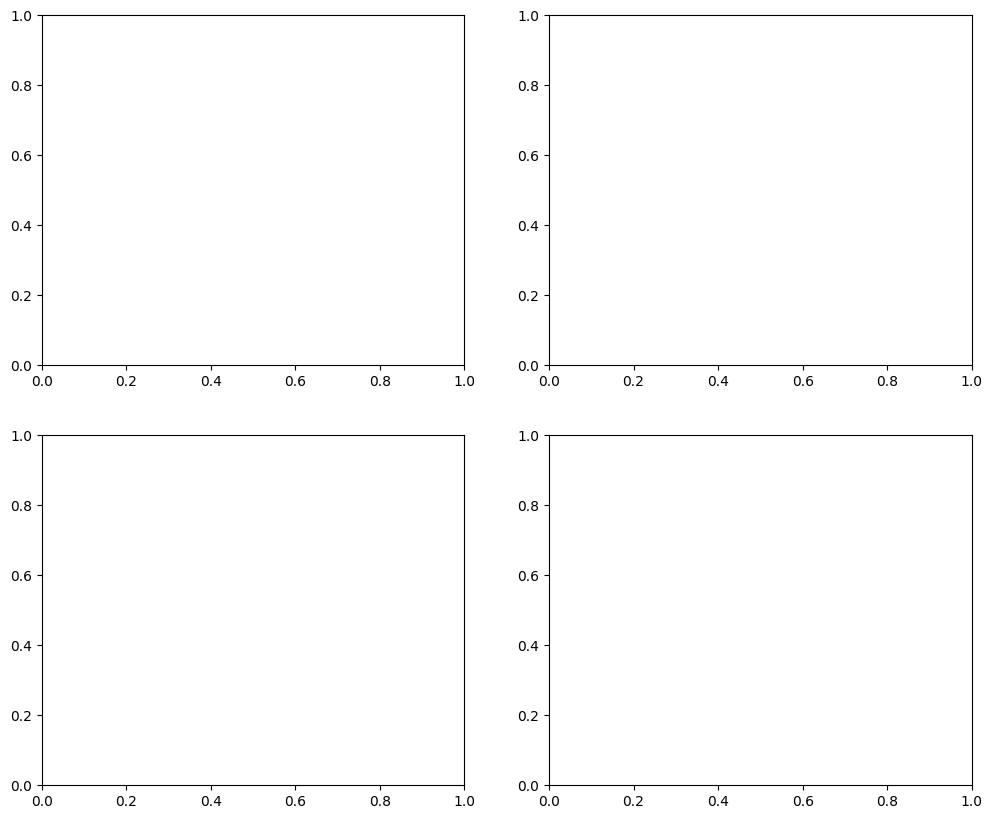

In [72]:
# Plot training history
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Age loss
axes[0, 0].plot(history.history['age_output_loss'], label='Train')
axes[0, 0].plot(history.history['val_age_output_loss'], label='Validation')
axes[0, 0].set_title('Age Prediction Loss (MSE)')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Age MAE
axes[0, 1].plot(history.history['age_output_mae'], label='Train')
axes[0, 1].plot(history.history['val_age_output_mae'], label='Validation')
axes[0, 1].set_title('Age Prediction MAE')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('MAE (years)')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Sex loss
axes[1, 0].plot(history.history['sex_output_loss'], label='Train')
axes[1, 0].plot(history.history['val_sex_output_loss'], label='Validation')
axes[1, 0].set_title('Sex Prediction Loss (BCE)')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Sex accuracy
axes[1, 1].plot(history.history['sex_output_accuracy'], label='Train')
axes[1, 1].plot(history.history['val_sex_output_accuracy'], label='Validation')
axes[1, 1].set_title('Sex Prediction Accuracy')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

# Scatter plot: Predicted vs True Age
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.scatter(y_age_val, pred_age, alpha=0.7)
ax.plot([y_age_val.min(), y_age_val.max()], 
        [y_age_val.min(), y_age_val.max()], 
        'r--', lw=2, label='Perfect Prediction')
ax.set_xlabel('True Age (years)')
ax.set_ylabel('Predicted Age (years)')
ax.set_title('Age Prediction: Predicted vs True')
ax.legend()
ax.grid(True)
plt.show()

print("Visualization complete!")